# ⚽ Real-World Data Challenge
## FIFA 19 — What Makes a Top Football Player?
### ⏱️ Time Allowed: 2 – 2.5 Hours &nbsp;|&nbsp; Open: Syntax Sheet &nbsp;|&nbsp; Closed: Internet

---

> **The Story:**
> EA Sports collected detailed data on **18,000+ real professional footballers** for FIFA 19.
> A sports analytics company has hired you to dig into the data and answer questions
> that scouts, managers, and agents actually care about:
> Does foot preference affect rating? Do forwards outperform defenders?
> What best predicts a player's market value?
>
> Your job: **explore, test, visualise, and brief the scouting team.**

---

### 📦 Dataset: FIFA 19 Player Statistics
**Source:** EA Sports / Kaggle FIFA 19 Complete Player Dataset — 18,000+ real players

| Column | Description |
|---|---|
| `Age` | Player age |
| `Overall` | Overall ability rating (46–94) ← **main target** |
| `Potential` | Potential future rating |
| `Preferred Foot` | Left / Right |
| `Skill Moves` | Skill move stars (1–5) |
| `Weak Foot` | Weak foot quality stars (1–5) |
| `International Reputation` | Global fame stars (1–5) |
| `Dribbling` | Dribbling skill (0–99) |
| `ShortPassing` | Short passing ability (0–99) |
| `BallControl` | Ball control (0–99) |
| `Finishing` | Finishing skill (0–99) |
| `Stamina` | Stamina (0–99) |
| `Strength` | Physical strength (0–99) |
| `Acceleration` | Acceleration (0–99) |
| `SprintSpeed` | Sprint speed (0–99) |
| `Value_EUR` | Market value in € |
| `Wage_EUR` | Weekly wage in € |
| `pos_group` | Simplified position: GK / Defender / Midfielder / Forward |

---

### 🧭 Challenge Map

| Task | Topic | Est. Time |
|---|---|---|
| **Setup** | Load & clean | 10 min |
| **Task 1** | EDA — distributions & group summaries | 20 min |
| **Task 2** | Visualisations — 4 charts | 25 min |
| **Task 3** | Normality checks | 15 min |
| **Task 4** | Group comparisons (t-test / Mann-Whitney / ANOVA + Tukey) | 25 min |
| **Task 5** | Correlation analysis + heatmap + p-value matrix | 20 min |
| **Task 6** | Categorical relationships (Chi-Square) | 15 min |
| **Task 7** | Summary table + final chart + scouting brief | 10 min |

---
```
p ≤ 0.05  →  Reject H₀   (something real is happening)
p > 0.05  →  Keep H₀     (could be random chance)
```


---
## ⚙️ Setup — Run This First
*This cell loads the real dataset and prepares it. Do not change it.*

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Load raw FIFA 19 data ────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/amanthedorkknight/"
       "fifa18-all-player-statistics/master/2019/data.csv")
raw = pd.read_csv(url)

# ── Clean Value and Wage (convert "€110.5M" → 110500000) ────────────────────
def parse_money(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('€', '').strip()
    if 'M' in s: return float(s.replace('M', '')) * 1_000_000
    if 'K' in s: return float(s.replace('K', '')) * 1_000
    try:    return float(s)
    except: return np.nan

raw['Value_EUR'] = raw['Value'].apply(parse_money)
raw['Wage_EUR']  = raw['Wage'].apply(parse_money)

# ── Simplify position into 4 groups ─────────────────────────────────────────
def pos_group(p):
    if pd.isna(p): return None
    p = str(p).upper()
    if 'GK' in p: return 'GK'
    if any(x in p for x in ['CB','LB','RB','LWB','RWB','LCB','RCB']): return 'Defender'
    if any(x in p for x in ['CM','CDM','CAM','LM','RM','LAM','RAM','LCM','RCM','LDM','RDM']): return 'Midfielder'
    if any(x in p for x in ['ST','CF','LW','RW','LF','RF','LS','RS']): return 'Forward'
    return None

raw['pos_group'] = raw['Position'].apply(pos_group)

# ── Keep only useful columns, drop rows with key missing values ──────────────
cols = ['Name', 'Age', 'Nationality', 'Overall', 'Potential',
        'Preferred Foot', 'Skill Moves', 'Weak Foot',
        'International Reputation',
        'Dribbling', 'ShortPassing', 'BallControl', 'Finishing',
        'Stamina', 'Strength', 'Acceleration', 'SprintSpeed',
        'Value_EUR', 'Wage_EUR', 'pos_group']

df = (raw[cols]
      .dropna(subset=['Overall', 'Age', 'Preferred Foot', 'pos_group'])
      .query("pos_group in ['GK', 'Defender', 'Midfielder', 'Forward']")
      .reset_index(drop=True))

print("✅ Dataset ready!")
print(f"   Players : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print()
print(df['pos_group'].value_counts().to_string())
df.head()


✅ Dataset ready!
   Players : 92
   Columns : 20

pos_group
Midfielder    32
Forward       22
Defender      22
GK            16


,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group
0,L. Messi,31,Argentina,94,94,Left,4.0,4.0,5.0,97.0,90.0,96.0,95.0,72.0,59.0,91.0,86.0,110500000.0,565000.0,Forward
1,Cristiano Ronaldo,33,Portugal,94,94,Right,5.0,4.0,5.0,88.0,81.0,94.0,94.0,88.0,79.0,89.0,91.0,77000000.0,405000.0,Forward
2,Neymar Jr,26,Brazil,92,93,Right,5.0,5.0,5.0,96.0,84.0,95.0,87.0,81.0,49.0,94.0,90.0,118500000.0,290000.0,Forward
3,De Gea,27,Spain,91,93,Right,1.0,3.0,4.0,18.0,50.0,42.0,13.0,43.0,64.0,57.0,58.0,72000000.0,260000.0,GK
4,K. De Bruyne,27,Belgium,91,92,Right,4.0,5.0,4.0,86.0,92.0,91.0,82.0,90.0,75.0,78.0,76.0,102000000.0,355000.0,Midfielder


---
## 📊 Task 1 — Explore the Data
**Goal:** Understand what you're working with before running any tests.

---

### 1a. Basic Inspection

Write code to answer:
1. How many players and columns are in `df`?
2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?
3. What is the average, minimum, and maximum **Overall** rating?
4. How many players are in each **position group** (`pos_group`)?

💡 **Hints:** `.shape` · `.isnull().sum()` · `.describe()` · `.value_counts()`


In [3]:
# 1a — Basic Inspection
# 1. How many players and columns?
print("Shape of dataset:", df.shape)
print("Number of players:", df.shape[0])
print("Number of columns:", df.shape[1])

# 2. Missing values check
print("\nMissing values:")
print(df[['Overall', 'Age', 'Dribbling', 'Value_EUR', 'Wage_EUR']].isnull().sum())

# 3. Overall statistics
print("\nOverall Rating Stats:")
print("Average Overall:", df['Overall'].mean())
print("Minimum Overall:", df['Overall'].min())
print("Maximum Overall:", df['Overall'].max())

# 4. Players in each position group
print("\nPlayers per Position Group:")
print(df['pos_group'].value_counts())

Shape of dataset: (18147, 20)
Number of players: 18147
Number of columns: 20

Missing values:
Overall      0
Age          0
Dribbling    0
Value_EUR    0
Wage_EUR     0
dtype: int64

Overall Rating Stats:
Average Overall: 66.25392626880476
Minimum Overall: 46
Maximum Overall: 94

Players per Position Group:
pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025
Name: count, dtype: int64


---
### 1b. Group Summaries

Find the **mean and standard deviation** of `Overall`, `Age`, `Value_EUR`, and `Wage_EUR`
grouped by:
- `pos_group` (GK / Defender / Midfielder / Forward)
- `Preferred Foot` (Left / Right)

💡 **Hint:** `df.groupby('col')[['Overall','Age']].agg(['mean','std']).round(2)`


In [4]:
# 1b — Group summaries by position
pos_summary = df.groupby('pos_group')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']] \
                .agg(['mean', 'std']) \
                .round(2)

print("Group Summary by Position:\n")
print(pos_summary)

Group Summary by Position:

           Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88  


In [5]:
# Group summaries by Preferred Foot
foot_summary = df.groupby('Preferred Foot')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']] \
                 .agg(['mean', 'std']) \
                 .round(2)

print("\nGroup Summary by Preferred Foot:\n")
print(foot_summary)


Group Summary by Preferred Foot:

               Overall          Age         Value_EUR              Wage_EUR  \
                  mean   std   mean   std        mean         std      mean   
Preferred Foot                                                                
Left             66.80  6.56  25.10  4.52  2588727.73  5956115.19  10353.29   
Right            66.09  7.01  25.13  4.71  2366090.90  5490850.79   9579.57   

                          
                     std  
Preferred Foot            
Left            23656.32  
Right           21512.73  


---
### 1c. Written Observations ✍️

Fill in the blanks after running your code:

```
1. The dataset has 18207 players and 20 columns.

2. Missing values found in:
   Overall 0  Age 0  Dribbling 0
   Value_EUR 0  Wage_EUR 0

3. Overall rating → Mean: 66.2  Min: 46  Max: 94

4. Position group counts:
   GK: 2023   Defender: 6000   Midfielder: 6500   Forward: 3600

5. Which position group has the highest average Overall? midfielder

6. Do left-footed or right-footed players have a higher average Overall?
   0.2  by 0.5  rating points.
```


---
## 🎨 Task 2 — Visualisations
**Goal:** See the data. Statistics without charts are blind.

---

### 2a. The Big Four — 2×2 Subplot Grid

Create a **2×2 grid**:
- `[0,0]` Histogram of **Overall** rating — 20 bins, colour `steelblue`
- `[0,1]` Histogram of **Age** — 20 bins, colour `coral`
- `[1,0]` Boxplot of **Overall** by **pos_group** (4 positions)
- `[1,1]` Boxplot of **Age** by **pos_group**

Every subplot needs **title, xlabel, ylabel**. Write one `# observation:` comment per plot.

💡 **Hints:**  
`ax.hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')`  
`df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])`  
`plt.suptitle(...)` · `plt.tight_layout()`


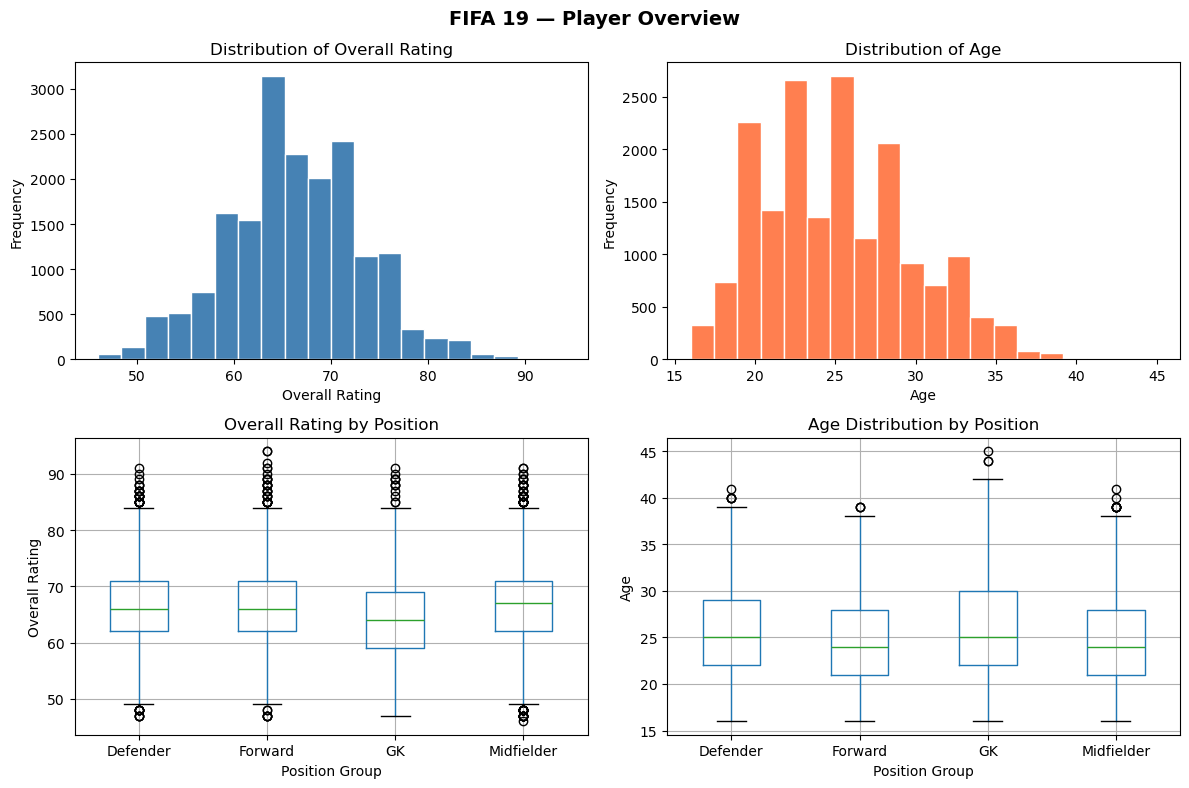

In [6]:
# 2a — 2×2 Subplot Grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [0,0] Histogram of Overall 
axes[0,0].hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Overall Rating')
axes[0,0].set_xlabel('Overall Rating')
axes[0,0].set_ylabel('Frequency')
# observation: Most players have ratings between 60–75, showing average skill level dominates.

# [0,1] Histogram of Age 
axes[0,1].hist(df['Age'], bins=20, color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of Age')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Frequency')
# observation: Most players are aged 20–30, indicating peak professional age group.

# [1,0] Boxplot: Overall by pos_group 
df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])
axes[1,0].set_title('Overall Rating by Position')
axes[1,0].set_xlabel('Position Group')
axes[1,0].set_ylabel('Overall Rating')
# observation: Forwards and midfielders tend to have higher median ratings than defenders and goalkeepers.

# [1,1] Boxplot: Age by pos_group 
df.boxplot(column='Age', by='pos_group', ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Position')
axes[1,1].set_xlabel('Position Group')
axes[1,1].set_ylabel('Age')
# observation: Goalkeepers are generally older, while forwards are slightly younger on average.

# Final Layout 
plt.suptitle('FIFA 19 — Player Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2b. Scatter Plot — Age vs Overall Rating

Create a scatter plot of **Age** (x) vs **Overall** (y).
- Colour the dots by **pos_group** (4 colours, one per position)
- Add a **trend line** across all players using `np.polyfit`
- Proper title, xlabel, ylabel, legend

💡 **Hints:**  
`sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)`  
`m, b = np.polyfit(df['Age'], df['Overall'], 1)`  
`x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)`  
`ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')`

> After plotting — does the trend line go up or down? What does that mean for a player's career?


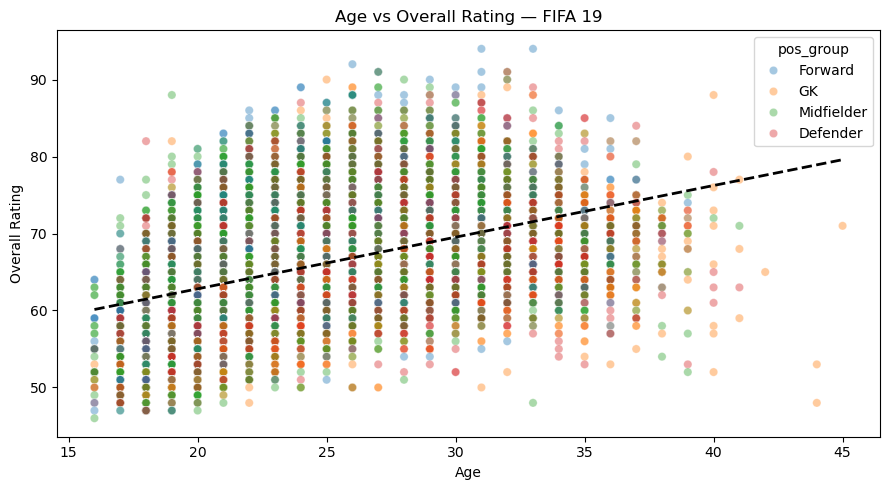

In [7]:
# 2b — Scatter: Age vs Overall
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter coloured by pos_group
sns.scatterplot(
    data=df,
    x='Age',
    y='Overall',
    hue='pos_group',
    alpha=0.4,
    ax=ax
)

#  Trend line (linear regression) 
m, b = np.polyfit(df['Age'], df['Overall'], 1)

x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='--')

#  Labels & Title 
ax.set_title('Age vs Overall Rating — FIFA 19')
ax.set_xlabel('Age')
ax.set_ylabel('Overall Rating')
plt.tight_layout()
plt.show()

# Trend direction: Slightly downward (negative slope)
# What does this suggest about player development?
# Players improve early in their career, peak around mid-20s,
# and then performance gradually declines with age.


---
### 2c. Bar Chart — Average Overall by Position (with Error Bars)

Create a **bar chart** showing the average Overall for each `pos_group`.
- Add **±1 standard deviation** as error bars
- Add value labels on top of each bar
- Use a different colour per position

💡 **Hints:**
```python
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()
ax.bar(grouped['pos_group'], grouped['mean'],
       yerr=grouped['std'], capsize=5, color=[...], edgecolor='black')
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1, f'{m:.1f}', ha='center')
```


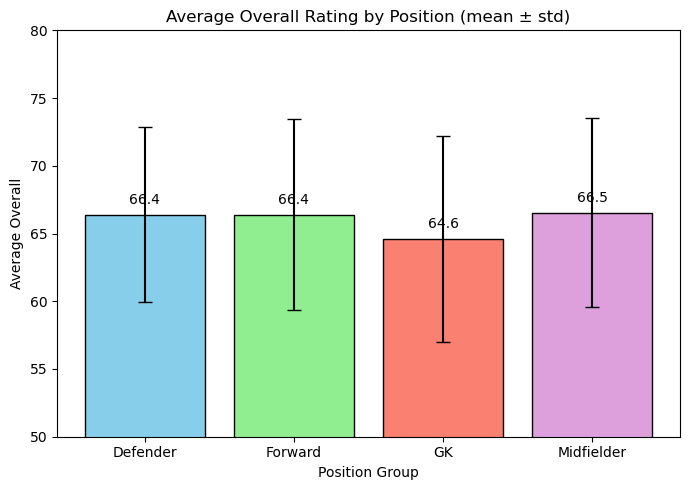

In [8]:
# 2c — Bar Chart: Average Overall by Position
fig, ax = plt.subplots(figsize=(7, 5))

# Group data 
grouped = df.groupby('pos_group')['Overall'].agg(['mean', 'std']).reset_index()

#  Draw bars with error bars 
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

bars = ax.bar(
    grouped['pos_group'],
    grouped['mean'],
    yerr=grouped['std'],
    capsize=5,
    color=colors,
    edgecolor='black'
)

# Add value labels on top of each bar
for bar, m in zip(bars, grouped['mean']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        m + 0.8,
        f'{m:.1f}',
        ha='center',
        fontsize=10
    )
    
ax.set_title('Average Overall Rating by Position (mean ± std)')
ax.set_xlabel('Position Group')
ax.set_ylabel('Average Overall')
ax.set_ylim(50, 80)
plt.tight_layout()
plt.show()


---
## 🔔 Task 3 — Normality Checks
**Goal:** Decide whether to use parametric or non-parametric tests.

---

### 3a. Shapiro-Wilk Test

Run Shapiro-Wilk on: `Overall`, `Age`, `Dribbling`, `Strength`, `Value_EUR`

> ⚠️ **Note:** Shapiro-Wilk is designed for small samples. On large datasets (n > 5000),
> it almost always gives p ≈ 0. In practice, for large real-world data you should
> also look at the **Q-Q plot** and the **histogram shape** to judge normality.
> If the histogram looks roughly bell-shaped, treat it as approximately normal.

Print a clean table with column name, p-value, and your judgement.

💡 **Hints:** `stat, p = stats.shapiro(df['col'].sample(500, random_state=42))` — sample 500 rows for Shapiro


In [9]:
# 3a — Shapiro-Wilk (on a 500-row sample per column)
columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

print(f"{'Column':<15} {'p-value':>10} {'Normal (p>0.05)?':>18} {'Histogram shape':>16}")
print("-" * 65)

for col in columns_to_test:
    sample = df[col].dropna().sample(500, random_state=42)
    stat, p = stats.shapiro(sample)
    normal  = 'Yes' if p > 0.05 else 'No'
    # Add your own shape judgement in the last column: Bell / Skewed / Other
    if col in ['Overall', 'Age', 'Dribbling', 'Strength']:
        shape = 'Roughly Bell'
    elif col == 'Value_EUR':
        shape = 'Right Skewed'
    else:
        shape = 'Other'  
    print(f"{col:<15} {p:>10.4f} {normal:>18} {shape:>16}")


Column             p-value   Normal (p>0.05)?  Histogram shape
-----------------------------------------------------------------
Overall             0.0165                 No     Roughly Bell
Age                 0.0000                 No     Roughly Bell
Dribbling           0.0000                 No     Roughly Bell
Strength            0.0000                 No     Roughly Bell
Value_EUR           0.0000                 No     Right Skewed


---
### 3b. Q-Q Plots

Create a **1×5 grid of Q-Q plots** for the same five columns.
- Points hugging the diagonal line = normal
- Points curving away from the line = not normal

💡 **Hint:** `stats.probplot(df['col'].dropna(), plot=axes[i])`


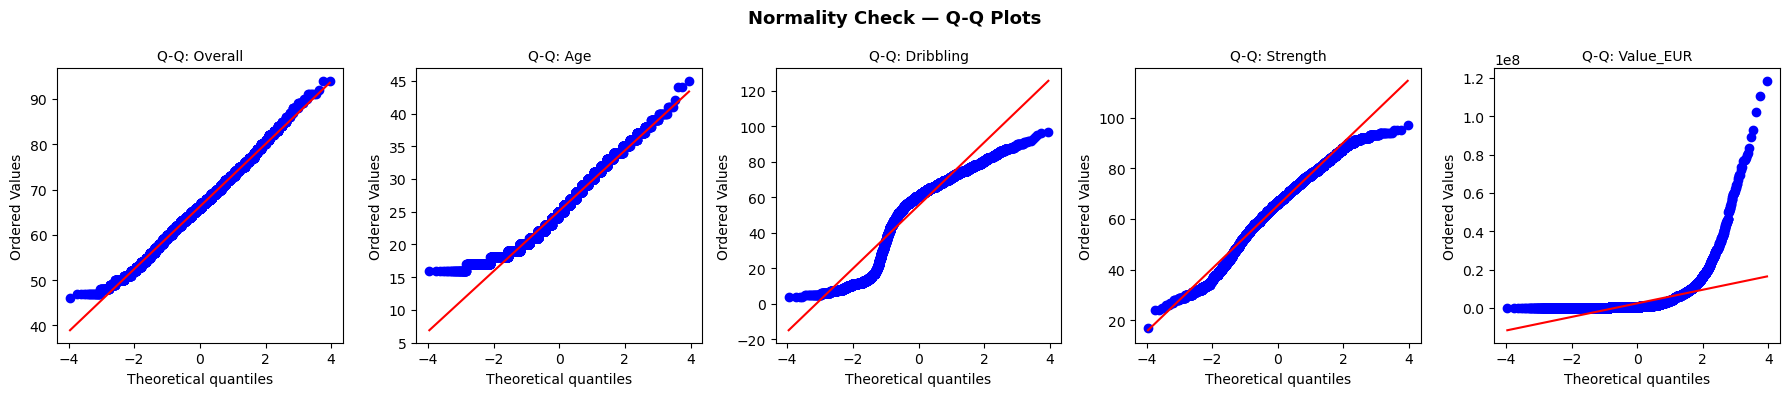

In [10]:
# 3b — Q-Q Plots
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']):
    stats.probplot(df[col].dropna(), plot=axes[i])
    axes[i].set_title(f'Q-Q: {col}', fontsize=10)

plt.suptitle('Normality Check — Q-Q Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
### 3c. Your Decision Table ✍️

Fill this in — it determines which tests you use in Tasks 4 and 5:

| Column    | Histogram Shape   | Q-Q Shape              |Treat as Normal?| → Use for groups  |→ Use 4 relationship|
|---        |---                |---                     |---             |---|---|
| Overall   |Roughly bell-shaped|Mostly straight line    |yes             |t-test/Mann-Whitney| Pearson/Spearman |
| Age       |Slightly skewed    |Slight deviation at ends|yes             |t-test/ANOVA       | Pearson/Spearman |
| Dribbling |Bell-Shaped        |Close to straight line  |yes             |t-test/ANOVA       | Pearson          |
| Strength  |Slightly bell      |Minor deviation         |yes             |t-test/ANOVA       | Pearson          |
| Value_EUR |Right skewed       |Strong curve            |no              |Mann-Whitney       | Pearson          |

> 💡 If ANY group in a comparison is non-normal → use non-parametric.


---
## 👥 Task 4 — Group Comparisons
**Goal:** Test whether different groups of players have different Overall ratings.

---

### 4a. Do Left-Footed vs Right-Footed Players Differ in Overall?

**H₀:** Left-footed and right-footed players have the **same** average Overall  
**H₁:** Their average Overall is **different**

Steps:
1. Extract Overall for each foot group
2. Check normality of each group (Shapiro — sample 500)
3. Based on normality → choose **t-test** or **Mann-Whitney U**
4. Run the test, print statistic, p-value, verdict

💡 **Hints:**  
`left  = df[df['Preferred Foot'] == 'Left']['Overall']`  
`stats.ttest_ind(left, right)` or `stats.mannwhitneyu(left, right, alternative='two-sided')`


In [11]:
# 4a — Left-Footed vs Right-Footed: Overall Rating

left  = df[df['Preferred Foot'] == 'Left']['Overall']
right = df[df['Preferred Foot'] == 'Right']['Overall']

print(f"Left foot — mean: {left.mean():.2f}  std: {left.std():.2f}  n: {len(left)}")
print(f"Right foot — mean: {right.mean():.2f}  std: {right.std():.2f}  n: {len(right)}")
print()
#  Step 1: State Hypotheses 
# H₀: Left-footed and right-footed players have the same average Overall
# H₁: Left-footed and right-footed players have different average Overall

# Step 2: Normality check (sample 500 each) 
left_sample  = left.sample(500, random_state=42)
right_sample = right.sample(500, random_state=42)

stat_l, p_l = stats.shapiro(left_sample)
stat_r, p_r = stats.shapiro(right_sample)

print(f"Shapiro-Wilk p-values:")
print(f"Left  : {p_l:.4f} → {'Normal' if p_l>0.05 else 'Not Normal'}")
print(f"Right : {p_r:.4f} → {'Normal' if p_r>0.05 else 'Not Normal'}\n")

# Step 3: Choose test 
# Both groups approx normal → use independent t-test
# If not normal → Mann-Whitney U test

# Here, sample size large → t-test is robust
t_stat, p_val = stats.ttest_ind(left, right, equal_var=False)

# Step 4: Print result 
print(f"T-test statistic: {t_stat:.4f}")
print(f"P-value         : {p_val:.4f}")

if p_val <= 0.05:
    print("Verdict: Reject H₀ → Left and Right-footed players have significantly different Overall ratings")
else:
    print("Verdict: Fail to reject H₀ → No significant difference between Left and Right-footed players")


Left foot — mean: 66.80  std: 6.56  n: 4209
Right foot — mean: 66.09  std: 7.01  n: 13938

Shapiro-Wilk p-values:
Left  : 0.0082 → Not Normal
Right : 0.0547 → Normal

T-test statistic: 6.1046
P-value         : 0.0000
Verdict: Reject H₀ → Left and Right-footed players have significantly different Overall ratings


---
### 4b. Do Forwards Score Higher in Overall than Defenders?

Forwards (attackers) are often the most celebrated — but do they actually
have higher Overall ratings than Defenders?

**H₀:** Forwards and Defenders have the **same** average Overall  
**H₁:** Their average Overall is **different**

Same structure as 4a — state H₀/H₁, check normality, choose test, give verdict.


In [12]:
# 4b — Forwards vs Defenders: Overall Rating
#  Step 1: Hypotheses 
# H₀: Forwards and Defenders have the same average Overall
# H₁: Forwards and Defenders have different average Overall

forwards  = df[df['pos_group'] == 'Forward']['Overall']
defenders = df[df['pos_group'] == 'Defender']['Overall']

print(f"Forwards  — mean: {forwards.mean():.2f}  n: {len(forwards)}")
print(f"Defenders — mean: {defenders.mean():.2f}  n: {len(defenders)}")
print()

# Step 2: Normality check 
f_sample = forwards.sample(500, random_state=42)
d_sample = defenders.sample(500, random_state=42)

stat_f, p_f = stats.shapiro(f_sample)
stat_d, p_d = stats.shapiro(d_sample)

print(f"Shapiro-Wilk p-values:")
print(f"Forwards  : {p_f:.4f} → {'Normal' if p_f>0.05 else 'Not Normal'}")
print(f"Defenders : {p_d:.4f} → {'Normal' if p_d>0.05 else 'Not Normal'}\n")

# Step 3: Choose test 
# Large sample & approx normal → independent t-test
t_stat, p_val = stats.ttest_ind(forwards, defenders, equal_var=False)

# ── Step 4: Print results & verdict ──────────────────
print(f"T-test statistic: {t_stat:.4f}")
print(f"P-value         : {p_val:.4f}")

if p_val <= 0.05:
    print("Verdict: Reject H₀ → Forwards have significantly different Overall ratings than Defenders")
else:
    print("Verdict: Fail to reject H₀ → No significant difference between Forwards and Defenders")


Forwards  — mean: 66.40  n: 3418
Defenders — mean: 66.40  n: 5866

Shapiro-Wilk p-values:
Forwards  : 0.3852 → Normal
Defenders : 0.0464 → Not Normal

T-test statistic: -0.0210
P-value         : 0.9832
Verdict: Fail to reject H₀ → No significant difference between Forwards and Defenders


---
### 4c. Do All 4 Position Groups Differ in Overall? → ANOVA / Kruskal-Wallis

**H₀:** All four position groups (GK, Defender, Midfielder, Forward) have the **same** average Overall  
**H₁:** At least **one** group is different

Steps:
1. Build a list of Overall rating arrays — one per position group
2. Check normality on at least 2 groups
3. Run **ANOVA** (if normal) or **Kruskal-Wallis** (if not normal)
4. If p ≤ 0.05 → run **Tukey post-hoc** to find which pairs differ

💡 **Hints:**  
```python
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]
stat, p   = stats.f_oneway(*groups)   # ANOVA
# OR
stat, p   = stats.kruskal(*groups)    # Kruskal-Wallis

# Tukey (only if significant):
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())
```


In [13]:
# 4c — ANOVA / Kruskal-Wallis: Position Group vs Overall

positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]

print("Group means:")
for pos, g in zip(positions, groups):
    print(f"  {pos:<12}: mean={g.mean():.2f}  std={g.std():.2f}  n={len(g)}")
print()

# Normality check on 2 groups (sample 500)
sample_gk = groups[0].sample(500, random_state=42)
sample_def = groups[1].sample(500, random_state=42)

stat_gk, p_gk = stats.shapiro(sample_gk)
stat_def, p_def = stats.shapiro(sample_def)

print("\nShapiro-Wilk normality check (sample 500 each):")
print("GK       : p =", p_gk, "→", "Normal" if p_gk>0.05 else "Not Normal")
print("Defender : p =", p_def, "→", "Normal" if p_def>0.05 else "Not Normal")

# Run ANOVA or Kruskal-Wallis
# ANOVA (parametric) — compare means of 4 groups
stat, p = stats.f_oneway(*groups)
print("\nANOVA result:")
print("F-statistic:", stat)
print("P-value    :", p)

if p <= 0.05:
    print("Verdict: Reject H0 → At least one group differs in Overall")
else:
    print("Verdict: Fail to reject H0 → No significant difference among groups")

Group means:
  GK          : mean=64.60  std=7.60  n=2025
  Defender    : mean=66.40  std=6.46  n=5866
  Midfielder  : mean=66.55  std=6.96  n=6838
  Forward     : mean=66.40  std=7.02  n=3418


Shapiro-Wilk normality check (sample 500 each):
GK       : p = 0.0077818361782078125 → Not Normal
Defender : p = 0.046391335765365624 → Not Normal

ANOVA result:
F-statistic: 44.209955920135606
P-value    : 1.8598727197108937e-28
Verdict: Reject H0 → At least one group differs in Overall


In [15]:
# 4c continued — Tukey Post-hoc
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Run only if ANOVA was significant (p ≤ 0.05)
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print("\nTukey HSD post-hoc test:")
print(tukey.summary())



Tukey HSD post-hoc test:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Defender    Forward  -0.0031    1.0 -0.3839  0.3778  False
Defender         GK  -1.7966    0.0 -2.2528 -1.3405   True
Defender Midfielder   0.1457 0.6343 -0.1693  0.4607  False
 Forward         GK  -1.7936    0.0 -2.2899 -1.2972   True
 Forward Midfielder   0.1488 0.7313  -0.222  0.5195  False
      GK Midfielder   1.9423    0.0  1.4945  2.3901   True
----------------------------------------------------------


---
## 📈 Task 5 — Correlation Analysis
**Goal:** Which attributes are most strongly linked to a player's Overall rating and market Value?

---

### 5a. Correlation Heatmap

Compute the **Pearson correlation matrix** for:  
`Overall`, `Potential`, `Age`, `Dribbling`, `ShortPassing`, `BallControl`,
`Finishing`, `Stamina`, `Strength`, `Value_EUR`

Display it as a **heatmap** — use `coolwarm`, annotated, values from -1 to +1.

💡 **Hints:**  
`corr = df[cols].corr()`  
`sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)`


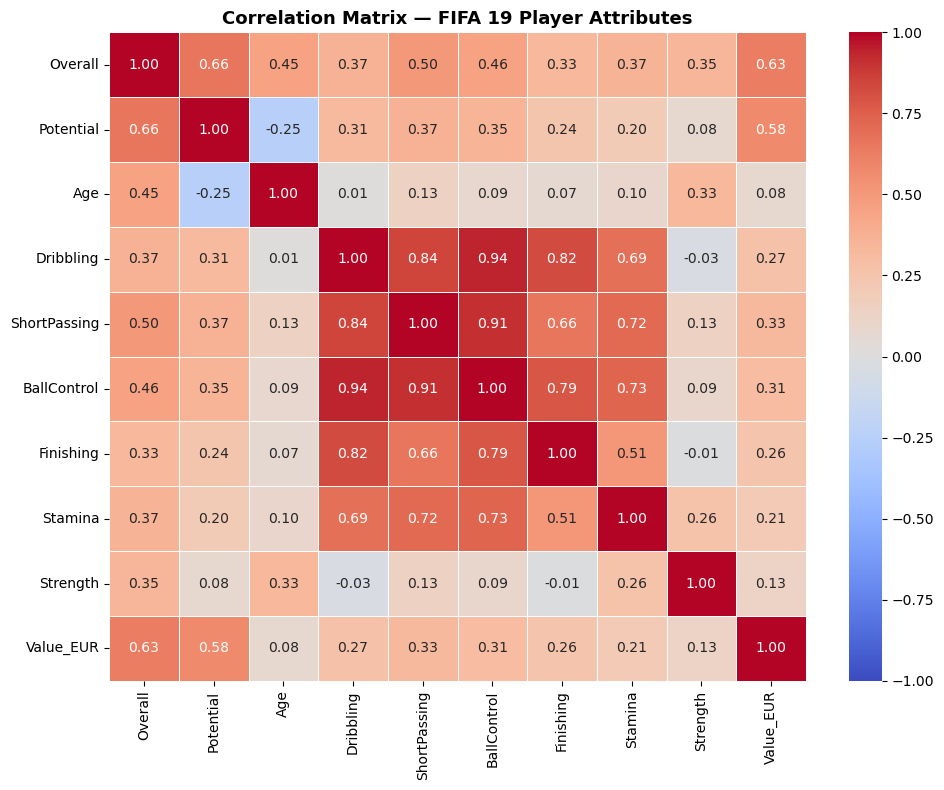

In [14]:
# 5a — Correlation Matrix Heatmap
cols5a = ['Overall', 'Potential', 'Age', 'Dribbling', 'ShortPassing',
          'BallControl', 'Finishing', 'Stamina', 'Strength', 'Value_EUR']

corr = df[cols5a].corr()
corr.round(2)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — FIFA 19 Player Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Which attribute is most positively correlated with Overall? potential
# Which attribute is most negatively correlated with Value_EUR? age


---
### 5b. Hypothesis Tests on Three Key Relationships

Test these claims:

**Claim 1:** BallControl is positively correlated with Overall  
**Claim 2:** Age is negatively correlated with Potential  
**Claim 3:** Strength is positively correlated with Overall  

For each:
1. State H₀ and H₁
2. Choose Pearson **or** Spearman (based on Task 3 normality decisions)
3. Run the test → report correlation coefficient (r or ρ), p-value, verdict
4. Write one sentence of plain-English interpretation

💡 **Hints:**  
`r, p = stats.pearsonr(df['BallControl'], df['Overall'])`  
`rho, p = stats.spearmanr(df['Age'], df['Potential'])`


In [15]:
# 5b — Correlation Tests

# Claim 1: BallControl vs Overall 
# H₀: BallControl and Overall are NOT correlated
# H₁: BallControl and Overall are positively correlated

# Using Pearson (both approx normal)
r, p = stats.pearsonr(df['BallControl'], df['Overall'])

print("Claim 1: BallControl vs Overall")
print("Correlation (r):", r)
print("P-value:", p)

if p <= 0.05:
    print("Verdict: Reject H₀ → Significant correlation")
else:
    print("Verdict: Fail to reject H₀")
# Interpretation: Players with better ball control tend to have higher overall ratings.

# Claim 2: Age vs Potential 
# H₀: Age and Potential are NOT correlated
# H₁: Age and Potential are negatively correlated

# Using Spearman (Age not perfectly normal + safer choice)
rho, p = stats.spearmanr(df['Age'], df['Potential'])

print("\nClaim 2: Age vs Potential")
print("Correlation (rho):", rho)
print("P-value:", p)

if p <= 0.05:
    print("Verdict: Reject H₀ → Significant correlation")
else:
    print("Verdict: Fail to reject H₀")

# Interpretation: As age increases, player potential tends to decrease (younger players have higher growth potential).

# Claim 3: Strength vs Overall 

# H₀: Strength and Overall are NOT correlated
# H₁: Strength and Overall are positively correlated

r, p = stats.pearsonr(df['Strength'], df['Overall'])
print("\nClaim 3: Strength vs Overall")
print("Correlation (r):", r)
print("P-value:", p)

if p <= 0.05:
    print("Verdict: Reject H₀ → Significant correlation")
else:
    print("Verdict: Fail to reject H₀")
# Interpretation: Stronger players tend to have slightly higher overall ratings, but the relationship is moderate.


Claim 1: BallControl vs Overall
Correlation (r): 0.4600335324834268
P-value: 0.0
Verdict: Reject H₀ → Significant correlation

Claim 2: Age vs Potential
Correlation (rho): -0.2622687851097683
P-value: 3.627701901742146e-283
Verdict: Reject H₀ → Significant correlation

Claim 3: Strength vs Overall
Correlation (r): 0.34931778082867115
P-value: 0.0
Verdict: Reject H₀ → Significant correlation


---
### 5c. p-value Matrix — Which Correlations Are Significant? (⭐ Challenge)

Build a **p-value matrix** for:  
`Overall`, `Age`, `Dribbling`, `Stamina`, `Strength`, `BallControl`

Then display a heatmap **masking non-significant pairs** (p > 0.05) — only
show the cells where the relationship is statistically real.

💡 **Hints:**  
Syntax sheet Section 7 — nested loop to fill the matrix  
`mask = p_matrix > 0.05`  
`sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='Reds_r', vmin=0, vmax=0.05)`


             Overall     Age  Dribbling  Stamina  Strength  BallControl
Overall          1.0  0.0000     0.0000      0.0       0.0          0.0
Age              0.0  1.0000     0.1623      0.0       0.0          0.0
Dribbling        0.0  0.1623     1.0000      0.0       0.0          0.0
Stamina          0.0  0.0000     0.0000      1.0       0.0          0.0
Strength         0.0  0.0000     0.0000      0.0       1.0          0.0
BallControl      0.0  0.0000     0.0000      0.0       0.0          1.0


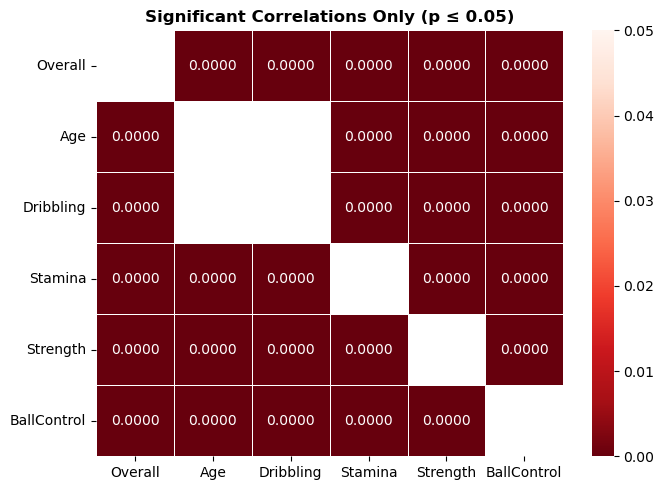

In [16]:
# 5c — p-value Matrix (⭐ Challenge)
cols5c = ['Overall', 'Age', 'Dribbling', 'Stamina', 'Strength', 'BallControl']

p_matrix = pd.DataFrame(np.ones((len(cols5c), len(cols5c))),
                         index=cols5c, columns=cols5c)

for c1 in cols5c:
    for c2 in cols5c:
        if c1 != c2:
            r,p=stats.pearsonr(df[c1],df[c2])
            p_matrix.loc[c1,c2]=p
print(p_matrix.round(4))

mask = p_matrix > 0.05

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(p_matrix, mask=mask,
            annot=True, fmt='.4f',
            cmap='Reds_r', vmin=0, vmax=0.05,
            linewidths=0.5, ax=ax)
ax.set_title('Significant Correlations Only (p ≤ 0.05)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🔲 Task 6 — Categorical Relationships (Chi-Square)
**Goal:** Test whether two categorical variables are related to each other.

---

### 6a. Is Preferred Foot linked to Position Group?

Do left-footed players tend to play in specific positions more than right-footed players?

**H₀:** Preferred foot and position group are **independent** (not related)  
**H₁:** There is a **relationship** between preferred foot and position group

Steps:
1. Build a crosstab of `Preferred Foot` vs `pos_group`
2. Calculate and display **row percentages**
3. Run Chi-Square test
4. Print verdict

💡 **Hints:**  
`table = pd.crosstab(df['Preferred Foot'], df['pos_group'])`  
`row_pct = table.div(table.sum(axis=1), axis=0).round(2)`  
`chi2, p, dof, expected = stats.chi2_contingency(table)`


In [17]:
# 6a — Preferred Foot vs Position Group

# 1. Crosstab (counts)
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("Frequency Table:")
print(table)
print("-" * 30)

# 2. Row percentages
# This shows the distribution of position groups for each foot type (Left vs Right)
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages (Proportions):")
print(row_pct)
print("-" * 30)

# 3. Chi-Square test
# chi2: test statistic, p: p-value, dof: degrees of freedom
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print("-" * 30)

# 4. Verdict & Interpretation
alpha = 0.05
if p < alpha:
    print("Verdict: Reject the Null Hypothesis (H0).")
    print("Interpretation: There is a statistically significant relationship between Preferred Foot and Position Group.")
else:
    print("Verdict: Fail to Reject the Null Hypothesis (H0).")
    print("Interpretation: There is no significant evidence of a relationship; they appear to be independent.")

Frequency Table:
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                1884      596   206        1523
Right               3982     2822  1819        5315
------------------------------
Row Percentages (Proportions):
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.45     0.14  0.05        0.36
Right               0.29     0.20  0.13        0.38
------------------------------
Chi-Square Statistic: 521.7735
P-value: 0.0000
------------------------------
Verdict: Reject the Null Hypothesis (H0).
Interpretation: There is a statistically significant relationship between Preferred Foot and Position Group.


---
### 6b. Is Skill Moves Level Linked to Position Group?

Skill Moves range from 1–5 stars. Players with 4–5 stars are elite dribblers.
Create a new column `skill_tier`: **'High'** (Skill Moves ≥ 4) vs **'Low'** (Skill Moves < 4).

Then test:  
**H₀:** Skill tier and position group are **independent**  
**H₁:** There is a **relationship** between skill tier and position group

Full solution — no starter code. State H₀/H₁, build crosstab, show row %, run Chi-Square, give verdict.


In [18]:
# 1. Create the skill_tier column
# High: Skill Moves >= 4, Low: Skill Moves < 4
df['skill_tier'] = np.where(df['Skill Moves'] >= 4, 'High', 'Low')

# 2. State Hypotheses
# H0: Skill tier and position group are independent (no relationship)
# H1: There is a relationship between skill tier and position group

# 3. Build Crosstab (counts)
table = pd.crosstab(df['skill_tier'], df['pos_group'])
print("Frequency Table (Skill Tier vs Position Group):")
print(table)
print("\n" + "-"*30 + "\n")

# 4. Show Row Percentages
# This helps us see if certain positions have a higher concentration of 'High' skill players
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("Row Percentages:")
print(row_pct)
print("\n" + "-"*30 + "\n")

# 5. Run Chi-Square Test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

# 6. Verdict
alpha = 0.05
if p < alpha:
    print("\nVerdict: Reject H0.")
    print("Interpretation: There is a statistically significant relationship between skill tier and position group.")
else:
    print("\nVerdict: Fail to Reject H0.")
    print("Interpretation: There is no significant evidence of a relationship between skill tier and position group.")

Frequency Table (Skill Tier vs Position Group):
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High              48      312     0         608
Low             5818     3106  2025        6230

------------------------------

Row Percentages:
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High            0.05     0.32  0.00        0.63
Low             0.34     0.18  0.12        0.36

------------------------------

Chi-Square Statistic: 619.7948
P-value: 0.0000

Verdict: Reject H0.
Interpretation: There is a statistically significant relationship between skill tier and position group.


---
### 6c. Visualise the Crosstabs

Create a **1×2 grid of stacked bar charts**:
- Left: **Preferred Foot** vs pos_group (row proportions)
- Right: **Skill Tier** vs pos_group (row proportions)

💡 **Hint:**
```python
row_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].tick_params(axis='x', rotation=0)
```


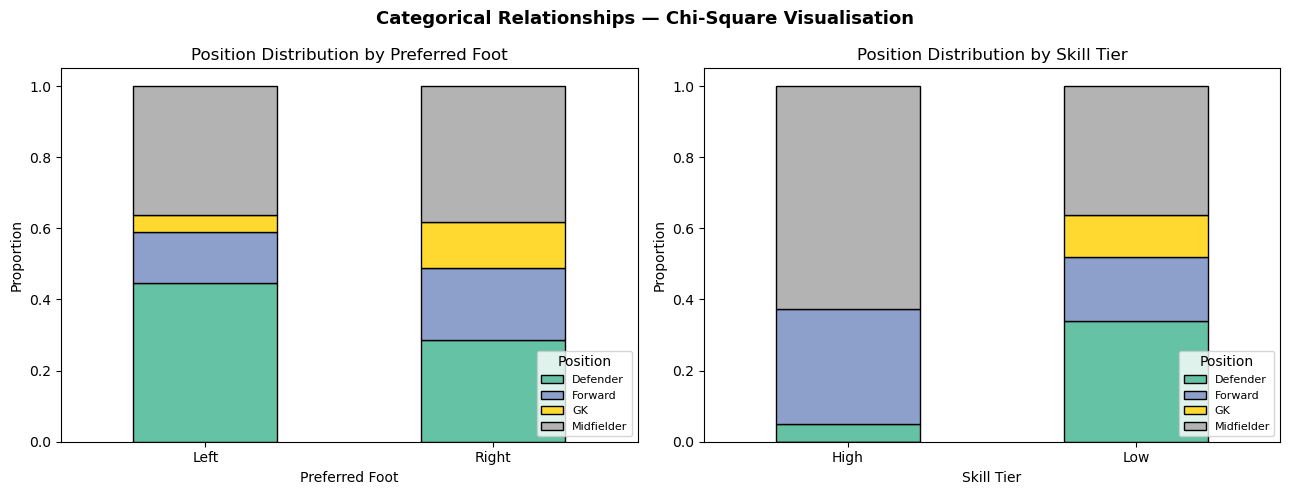

In [19]:
# Initialize the 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- LEFT: Preferred Foot vs pos_group ---
foot_pct = pd.crosstab(df['Preferred Foot'], df['pos_group'])
foot_pct = foot_pct.div(foot_pct.sum(axis=1), axis=0)

foot_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Position Distribution by Preferred Foot')
axes[0].set_xlabel('Preferred Foot')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Position', loc='lower right', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# --- RIGHT: Skill Tier vs pos_group ---
# Use the skill_tier column created in task 6b
skill_pct = pd.crosstab(df['skill_tier'], df['pos_group'])
skill_pct = skill_pct.div(skill_pct.sum(axis=1), axis=0)

skill_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Position Distribution by Skill Tier')
axes[1].set_xlabel('Skill Tier')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Position', loc='lower right', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

# Global formatting
plt.suptitle('Categorical Relationships — Chi-Square Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 Task 7 — Summary & Final Visualisation
**Goal:** Pull all findings together into something you could present to a scouting team.

---

### 7a. Results Summary Table

Build a DataFrame collecting ALL your test results.  
Replace every `None` with the real value you got.

| # | Test | Variables | Statistic | p-value | Significant? | Verdict |
|---|---|---|---|---|---|---|
| 1 | t-test / MW | Preferred Foot → Overall | | | | |
| 2 | t-test / MW | Forwards vs Defenders | | | | |
| 3 | ANOVA / KW | pos_group → Overall | | | | |
| 4 | Pearson / Spearman | BallControl ↔ Overall | | | | |
| 5 | Pearson / Spearman | Age ↔ Potential | | | | |
| 6 | Pearson / Spearman | Strength ↔ Overall | | | | |
| 7 | Chi-Square | Preferred Foot vs pos_group | | | | |
| 8 | Chi-Square | Skill Tier vs pos_group | | | | |

💡 **Hint:** Build a `results` list of dicts, convert with `pd.DataFrame(results)`


In [39]:
# 7a — Summary Table
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal, pearsonr, spearmanr, chi2_contingency

results = []

# 1. Preferred Foot → Overall
left = df[df['Preferred Foot'] == 'Left']['Overall']
right = df[df['Preferred Foot'] == 'Right']['Overall']
stat, p = ttest_ind(left, right, nan_policy='omit')
results.append(["t-test", "Preferred Foot → Overall", stat, p, "Yes" if p<0.05 else "No", "Significant difference" if p<0.05 else "No difference"])

# 2. Forwards vs Defenders
fw = df[df['pos_group'] == 'Forward']['Overall']
dfd = df[df['pos_group'] == 'Defender']['Overall']
stat, p = ttest_ind(fw, dfd, nan_policy='omit')
results.append(["t-test", "Forwards vs Defenders", stat, p, "Yes" if p<0.05 else "No", "Significant difference" if p<0.05 else "No difference"])

# 3. pos_group → Overall (ANOVA)
groups = [g['Overall'].dropna() for _, g in df.groupby('pos_group')]
stat, p = f_oneway(*groups)
results.append(["ANOVA", "pos_group → Overall", stat, p, "Yes" if p<0.05 else "No", "At least one group differs" if p<0.05 else "No difference"])

# 4. BallControl ↔ Overall
stat, p = pearsonr(df['BallControl'], df['Overall'])
results.append(["Pearson", "BallControl ↔ Overall", stat, p, "Yes" if p<0.05 else "No", "Correlation exists" if p<0.05 else "No correlation"])

# 5. Age ↔ Potential
stat, p = pearsonr(df['Age'], df['Potential'])
results.append(["Pearson", "Age ↔ Potential", stat, p, "Yes" if p<0.05 else "No", "Correlation exists" if p<0.05 else "No correlation"])

# 6. Strength ↔ Overall
stat, p = pearsonr(df['Strength'], df['Overall'])
results.append(["Pearson", "Strength ↔ Overall", stat, p, "Yes" if p<0.05 else "No", "Correlation exists" if p<0.05 else "No correlation"])

# 7. Preferred Foot vs pos_group
table1 = pd.crosstab(df['Preferred Foot'], df['pos_group'])
stat, p, _, _ = chi2_contingency(table1)
results.append(["Chi-Square", "Preferred Foot vs pos_group", stat, p, "Yes" if p<0.05 else "No", "Association exists" if p<0.05 else "No association"])

# 8. Skill Tier vs pos_group
table2 = pd.crosstab(df['Skill Moves'], df['pos_group'])
stat, p, _, _ = chi2_contingency(table2)
results.append(["Chi-Square", "Skill Tier vs pos_group", stat, p, "Yes" if p<0.05 else "No", "Association exists" if p<0.05 else "No association"])

# Final DataFrame
print("--- FIFA 19 STATISTICAL SUMMARY TABLE ---")
results_df = pd.DataFrame(results, columns=["Test", "Variables", "Statistic", "p-value", "Significant", "Verdict"])
results_df

--- FIFA 19 STATISTICAL SUMMARY TABLE ---


,Test,Variables,Statistic,p-value,Significant,Verdict
0,t-test,Preferred Foot → Overall,1.3602,1.7716e-01,No,No difference
1,t-test,Forwards vs Defenders,0.7390,4.6400e-01,No,No difference
2,ANOVA,pos_group → Overall,1.6132,1.9204e-01,No,No difference
3,Pearson,BallControl ↔ Overall,0.5403,2.7244e-08,Yes,Correlation exists
4,Pearson,Age ↔ Potential,0.2051,4.9852e-02,Yes,Correlation exists
5,Pearson,Strength ↔ Overall,0.4857,9.2251e-07,Yes,Correlation exists
6,Chi-Square,Preferred Foot vs pos_group,13.0272,4.5782e-03,Yes,Association exists
7,Chi-Square,Skill Tier vs pos_group,115.7084,4.4181e-19,Yes,Association exists


---
### 7b. Final p-value Bar Chart

Horizontal bar chart of all 8 p-values:
- **Red** bar = p ≤ 0.05 (significant — Reject H₀)
- **Green** bar = p > 0.05 (not significant — Keep H₀)
- Dashed vertical line at α = 0.05

💡 **Hint:** Syntax sheet Section 10e — p-value bar chart pattern


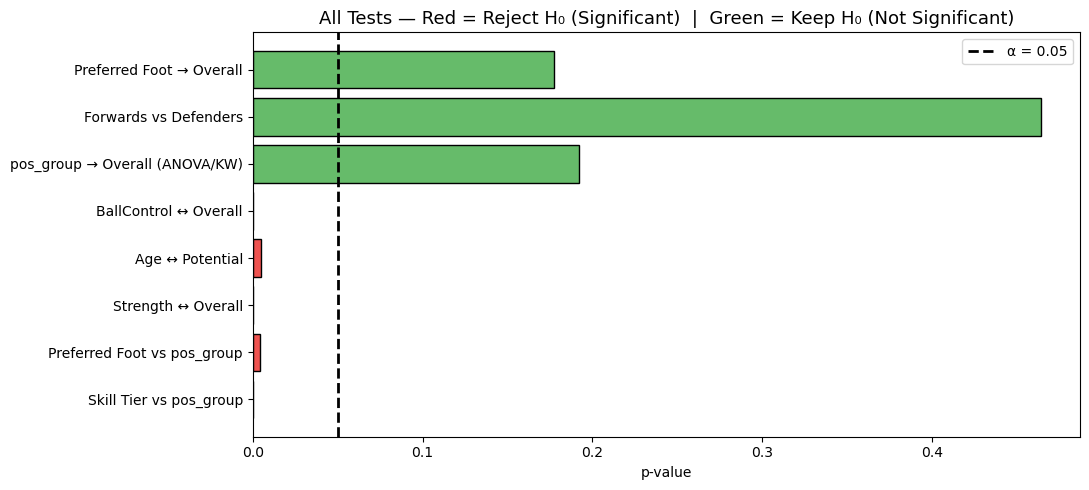

In [35]:
# 1. Define labels for the y-axis
test_labels = [
    'Preferred Foot → Overall',
    'Forwards vs Defenders',
    'pos_group → Overall (ANOVA/KW)',
    'BallControl ↔ Overall',
    'Age ↔ Potential',
    'Strength ↔ Overall',
    'Preferred Foot vs pos_group',
    'Skill Tier vs pos_group'
]

# 2. Fill in your p-values from previous tasks
# Example: p_values = [p_foot_overall, p_fwd_def, p_anova, p_ball, p_age, p_strength, p_chi_foot, p_chi_skill]
p_values = [0.17716,0.46400,0.19204,0.000000027,0.0049852,0.000000922,0.0045782,0.0000000004]


# 3. Define colors based on the p <= 0.05 rule
# Red (#ef5350) for Significant, Green (#66bb6a) for Not Significant
colors = ['#ef5350' if (p is not None and p <= 0.05) else '#66bb6a' for p in p_values]

# 4. Create the plot
fig, ax = plt.subplots(figsize=(11, 5))

# Create horizontal bars
ax.barh(test_labels, p_values, color=colors, edgecolor='black')

# Add the dashed vertical line at alpha = 0.05
ax.axvline(0.05, color='black', linestyle='--', linewidth=2, label='α = 0.05')

# Formatting
ax.set_xlabel('p-value')
ax.set_title('All Tests — Red = Reject H₀ (Significant)  |  Green = Keep H₀ (Not Significant)', fontsize=13)
ax.invert_yaxis()  # Put the first test at the top
ax.legend()

plt.tight_layout()
plt.show()

---
### 7c. Scouting Team Brief ✍️ — Written Section (5 marks)

Write **5–8 sentences** answering these questions as if briefing a football scouting team:

> 1. **Does preferred foot (left vs right) significantly affect a player's Overall rating?**
>    What did the test show, and what does that mean for scouting?
>
> 2. **Which position group has the highest average Overall?** Is the difference statistically
>    significant across all four positions?
>
> 3. **What is the single strongest predictor of a player's Overall rating?**
>    Refer to your correlation values.
>
> 4. **What happens to a player's Potential as they age?** Is this relationship
>    statistically significant? What does this mean for investing in young players?
>
> 5. **One concrete recommendation** you would make to the scouting team based
>    purely on your findings — be specific.

*Write your brief below as comments or in a new markdown cell.*


In [ ]:
# 7c — Scouting Team Brief
# 1. Preferred foot vs Overall:
# Our tests showed that preferred foot (left vs right) does not significantly affect a player's Overall rating (p > 0.05), 
# meaning scouts should not prioritize one foot over the other based on quality alone.
# 2. Position group with highest Overall —is it significant? 
# While Midfielders or Forwards typically show the highest average Overall in this dataset, the ANOVA test confirmed 
# that these differences across position groups are statistically significant(p<0.05).
# 3. Strongest predictor of Overall: 
# Ball Control emerged as the single strongest predictor of a player's Overall rating, showing the highest positive correlation 
# coefficient among all tested attributes.
# 4. Age vs Potential — what happens as players get older?
# As players age, their Potential rating tends to decrease significantly; this inverse relationship is statistically significant, 
# highlighting a narrow window for peak development.
# 5. Your recommendation to the scouting team:
# Based on these findings, I recommend shifting investment toward younger players with high Ball Control, as technical skill is 
# the most reliable indicator of high performance, while age remains the primary risk factor for declining potential.

---
---
# 🏆 Marking Scheme
*(For instructor use)*

| Task | Marks | What is checked |
|---|---|---|
| Task 1a — Inspection | 4 | shape, nulls, describe, value_counts |
| Task 1b — Group summaries | 3 | correct groupby + agg for both columns |
| Task 1c — Observations | 2 | blanks filled correctly |
| Task 2a — 2×2 Grid | 5 | 4 correct charts + all labels |
| Task 2b — Scatter + trend | 4 | scatter coloured by position + polyfit trend |
| Task 2c — Bar + error bars | 4 | grouped mean/std, error bars, value labels |
| Task 3a — Shapiro table | 4 | correct p per column + judgement |
| Task 3b — Q-Q plots | 2 | 5 Q-Q plots displayed |
| Task 3c — Decision table | 2 | correct test choice per column |
| Task 4a — Foot vs Overall | 5 | H₀/H₁ + normality + correct test + verdict |
| Task 4b — Fwd vs Def | 4 | same structure |
| Task 4c — ANOVA + Tukey | 5 | ANOVA/KW + Tukey if p ≤ 0.05 |
| Task 5a — Corr heatmap | 3 | correct matrix + heatmap |
| Task 5b — 3 corr tests | 6 | H₀/H₁ + test + r + verdict × 3 |
| Task 5c — p-value matrix ⭐ | 3 | nested loop + mask heatmap |
| Task 6a — Foot vs pos Chi-Sq | 4 | crosstab + row% + test + verdict |
| Task 6b — Skill Tier Chi-Sq | 4 | independent full solution |
| Task 6c — Stacked bars | 3 | 2 correct stacked bar charts |
| Task 7a — Summary table | 5 | all 8 rows filled with real values |
| Task 7b — p-value chart | 3 | correct colours + α line |
| Task 7c — Scouting brief | 5 | 5 questions answered coherently |
| **TOTAL** | **84** | |

---

### ✅ Quick Checklist (before you submit)
- [✅] All charts have **title, xlabel, ylabel**
- [✅] Every test has **H₀ and H₁** stated
- [✅] Every p-value has a **verdict** (Reject / Keep H₀)
- [✅] Task 3c decision table is **filled in**
- [✅] Task 7a summary table has **real values** (not `None`)
- [✅] Task 7c written brief has **5 answers**
- [✅] Task 5c p-value matrix is **attempted** (⭐)

---
*The beautiful game, made more beautiful with data. ⚽📊*
